In [1]:
import os
import time
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image


In [2]:

# ==========================================
# 1. CONFIGURATION (Optimized for 2 GPUs)
# ==========================================
class Config:
    # --- PATH SETUP ---
    DATA_DIR = "/kaggle/input/chexpert"
    if not os.path.exists(DATA_DIR):
        # Fallback check
        if os.path.exists("/kaggle/input/chexpert-v10-small"):
            DATA_DIR = "/kaggle/input/chexpert-v10-small"
            
    TRAIN_CSV = os.path.join(DATA_DIR, "train.csv")
    VALID_CSV = os.path.join(DATA_DIR, "valid.csv")
    
    # --- DUAL GPU SETTINGS ---
    IMG_SIZE = 320
    # We use 32 here because 16 images go to GPU_1 and 16 go to GPU_2
    BATCH_SIZE = 32  
    LEARNING_RATE = 1e-4
    EPOCHS = 3 
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    
    # Increase workers to feed 2 GPUs fast enough
    NUM_WORKERS = 4 
    
    LABELS = [
        'No Finding', 'Enlarged Cardiomediastinum', 'Cardiomegaly', 'Lung Opacity', 
        'Lung Lesion', 'Edema', 'Consolidation', 'Pneumonia', 'Atelectasis', 
        'Pneumothorax', 'Pleural Effusion', 'Pleural Other', 'Fracture', 
        'Support Devices'
    ]

📍 Dataset detected at: /kaggle/input/chexpert


In [4]:


# ==========================================
# 2. DATASET MODULE
# ==========================================
class CheXpertDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None, policy="u-ones"):
        self.data = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform
        self.policy = policy
        
    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        csv_path = self.data.iloc[idx, 0] 
        clean_path = csv_path.replace("CheXpert-v1.0-small/", "")
        full_path = os.path.join(self.root_dir, clean_path)
        
        try:
            image = Image.open(full_path).convert("RGB")
        except FileNotFoundError:
            return torch.zeros(3, Config.IMG_SIZE, Config.IMG_SIZE), torch.zeros(14)

        labels = self.data.iloc[idx][Config.LABELS].values.astype(float)
        
        if self.policy == "u-ones":
            labels = np.where(labels == -1.0, 1.0, labels)
        elif self.policy == "u-zeros":
            labels = np.where(labels == -1.0, 0.0, labels)
            
        labels = np.nan_to_num(labels, nan=0.0)
        labels = torch.tensor(labels, dtype=torch.float32)

        if self.transform:
            image = self.transform(image)

        return image, labels

In [5]:
# ==========================================
# 3. MODEL
# ==========================================
class CheXpertClassifier(nn.Module):
    def __init__(self, num_classes=14, is_trained=True):
        super(CheXpertClassifier, self).__init__()
        try:
            self.backbone = models.densenet121(weights="IMAGENET1K_V1")
        except:
            self.backbone = models.densenet121(pretrained=True)
            
        num_features = self.backbone.classifier.in_features
        self.backbone.classifier = nn.Sequential(
            nn.Linear(num_features, num_classes)
        )
        
    def forward(self, x):
        return self.backbone(x)

In [9]:
# ==========================================
# 4. TRAINING EXECUTION (With DataParallel)
# ==========================================
if __name__ == "__main__":
    print(f"🚀 Initializing Training...")
    
    # 1. Transforms
    train_transform = transforms.Compose([
        transforms.Resize((Config.IMG_SIZE, Config.IMG_SIZE)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    
    # 2. Data Loader
    train_dataset = CheXpertDataset(Config.TRAIN_CSV, Config.DATA_DIR, transform=train_transform)
    train_loader = DataLoader(
        train_dataset, 
        batch_size=Config.BATCH_SIZE, 
        shuffle=True, 
        num_workers=Config.NUM_WORKERS,
        pin_memory=True # Faster transfer to GPU
    )
    
    # 3. Model Setup & 2-GPU Logic
    model = CheXpertClassifier(num_classes=len(Config.LABELS))
    
    # CHECK FOR MULTIPLE GPUS
    if torch.cuda.device_count() > 1:
        print(f"🔥 found {torch.cuda.device_count()} GPUs! Using DataParallel.")
        model = nn.DataParallel(model)
    else:
        print("⚠️ Only 1 GPU found. Using standard mode.")
        
    model = model.to(Config.DEVICE)
    
    optimizer = optim.Adam(model.parameters(), lr=Config.LEARNING_RATE)
    criterion = nn.BCEWithLogitsLoss()
    
    print(f"✅ Starting Training on {torch.cuda.device_count()} GPUs with Batch Size {Config.BATCH_SIZE}...")
    
    for epoch in range(Config.EPOCHS):
        model.train()
        running_loss = 0.0
        start_time = time.time()
        
        for i, (images, labels) in enumerate(train_loader):
            images, labels = images.to(Config.DEVICE), labels.to(Config.DEVICE)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            
            if i % 50 == 0:
                print(f"Epoch {epoch+1} [Batch {i}/{len(train_loader)}] Loss: {loss.item():.4f}")
        
        end_time = time.time()
        print(f"⚠️ Epoch {epoch+1} Finished in {end_time - start_time:.0f}s. Avg Loss: {running_loss/len(train_loader):.4f}")
        
    print("Training Complete! Saving Model...")
    
    # SAVE FIX: Unwrap the model before saving
    # If we don't do this, the keys will be named 'module.features...' and won't load on a single GPU later.
    if isinstance(model, nn.DataParallel):
        torch.save(model.module.state_dict(), "chexpert_model_2gpu.pth")
    else:
        torch.save(model.state_dict(), "chexpert_model_1gpu.pth")
        
    print("💾 Model Saved.")

🚀 Initializing Training...
🔥 found 2 GPUs! Using DataParallel.
✅ Starting Training on 2 GPUs with Batch Size 32...
Epoch 1 [Batch 0/6982] Loss: 0.7083
Epoch 1 [Batch 50/6982] Loss: 0.3905
Epoch 1 [Batch 100/6982] Loss: 0.4329
Epoch 1 [Batch 150/6982] Loss: 0.3692
Epoch 1 [Batch 200/6982] Loss: 0.3592
Epoch 1 [Batch 250/6982] Loss: 0.4188
Epoch 1 [Batch 300/6982] Loss: 0.3555
Epoch 1 [Batch 350/6982] Loss: 0.3630
Epoch 1 [Batch 400/6982] Loss: 0.3457
Epoch 1 [Batch 450/6982] Loss: 0.3735
Epoch 1 [Batch 500/6982] Loss: 0.3501
Epoch 1 [Batch 550/6982] Loss: 0.3744
Epoch 1 [Batch 600/6982] Loss: 0.3841
Epoch 1 [Batch 650/6982] Loss: 0.3674
Epoch 1 [Batch 700/6982] Loss: 0.3509
Epoch 1 [Batch 750/6982] Loss: 0.3641
Epoch 1 [Batch 800/6982] Loss: 0.3520
Epoch 1 [Batch 850/6982] Loss: 0.3875
Epoch 1 [Batch 900/6982] Loss: 0.3604
Epoch 1 [Batch 950/6982] Loss: 0.3699
Epoch 1 [Batch 1000/6982] Loss: 0.4138
Epoch 1 [Batch 1050/6982] Loss: 0.3700
Epoch 1 [Batch 1100/6982] Loss: 0.3515
Epoch 1 [Ba

In [13]:
import os

# 1. Use the exact logic from your Config to find the root
DATA_DIR = "/kaggle/input/chexpert"
if not os.path.exists(DATA_DIR):
    if os.path.exists("/kaggle/input/chexpert-v10-small"):
        DATA_DIR = "/kaggle/input/chexpert-v10-small"

print(f"📍 data root: {DATA_DIR}")

# 2. Locate the 'valid' folder
# Sometimes it's directly in root, sometimes inside another CheXpert-v1.0-small folder
valid_path = os.path.join(DATA_DIR, "valid")
if not os.path.exists(valid_path):
    # Try the nested version
    valid_path = os.path.join(DATA_DIR, "CheXpert-v1.0-small", "valid")

if os.path.exists(valid_path):
    print(f"✅ Found Validation Folder: {valid_path}")
    
    # 3. List the first 5 patients found
    patients = [p for p in os.listdir(valid_path) if "patient" in p]
    patients.sort()
    
    if len(patients) > 0:
        print("\n📋 COPY ONE OF THESE IDs FOR TESTING:")
        for p in patients[:5]:
            print(f"   👉 {p}")
            
        # Verify the full path for the first one
        first_p = patients[0]
        full_p = os.path.join(valid_path, first_p, "study1", "view1_frontal.jpg")
        if os.path.exists(full_p):
             print(f"\n🖼️ Verified image path exists: {full_p}")
        else:
             # Check what IS inside
             study_path = os.path.join(valid_path, first_p, "study1")
             print(f"\n⚠️ Note: Files inside {first_p}/study1: {os.listdir(study_path)}")
    else:
        print("❌ valid folder exists but is empty!")
else:
    print(f"❌ Could not find 'valid' folder in {DATA_DIR}")
    print(f"Contents of root: {os.listdir(DATA_DIR)}")

📍 data root: /kaggle/input/chexpert
✅ Found Validation Folder: /kaggle/input/chexpert/valid

📋 COPY ONE OF THESE IDs FOR TESTING:
   👉 patient64541
   👉 patient64542
   👉 patient64543
   👉 patient64544
   👉 patient64545

🖼️ Verified image path exists: /kaggle/input/chexpert/valid/patient64541/study1/view1_frontal.jpg


📄 Found X-Ray: /kaggle/input/chexpert/valid/patient64541/study1/view1_frontal.jpg
🧠 Loading Model...


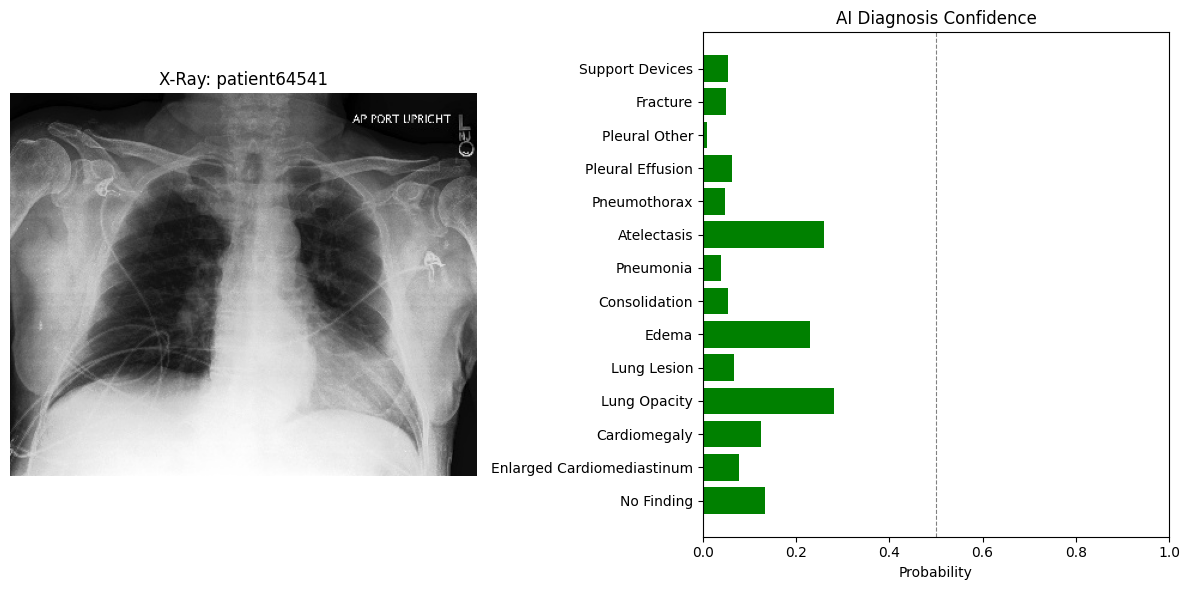


📋 REPORT FOR patient64541
------------------------------
✅ No pathologies detected.


In [16]:
import torch
import torch.nn as nn
from torchvision import transforms, models
from PIL import Image
import os
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. SETUP
# ==========================================
PATIENT_ID = "patient64541"
BASE_PATH = "/kaggle/input/chexpert/valid" 

LABELS = [
    'No Finding', 'Enlarged Cardiomediastinum', 'Cardiomegaly', 'Lung Opacity', 
    'Lung Lesion', 'Edema', 'Consolidation', 'Pneumonia', 'Atelectasis', 
    'Pneumothorax', 'Pleural Effusion', 'Pleural Other', 'Fracture', 
    'Support Devices'
]

# ==========================================
# 2. DEFINE THE CLASS (CRITICAL STEP)
# ==========================================
class CheXpertClassifier(nn.Module):
    def __init__(self, num_classes=14):
        super(CheXpertClassifier, self).__init__()
        # We don't need pretrained weights here, we will load our own
        self.backbone = models.densenet121(weights=None) 
        
        num_features = self.backbone.classifier.in_features
        self.backbone.classifier = nn.Sequential(
            nn.Linear(num_features, num_classes)
        )
        
    def forward(self, x):
        return self.backbone(x)

# ==========================================
# 3. PREDICTION FUNCTION
# ==========================================
def predict_patient(patient_id):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    
    # --- A. Locate Image ---
    patient_path = os.path.join(BASE_PATH, patient_id, "study1")
    try:
        img_filename = [f for f in os.listdir(patient_path) if f.endswith('.jpg')][0]
        full_img_path = os.path.join(patient_path, img_filename)
        print(f"📄 Found X-Ray: {full_img_path}")
    except Exception as e:
        print(f"❌ Error locating image: {e}")
        return

    # --- B. Load Model ---
    print("🧠 Loading Model...")
    
    # Initialize the CUSTOM class, not the raw DenseNet
    model = CheXpertClassifier(num_classes=14)
    
    # Load weights
    try:
        # Load to CPU first to be safe
        state_dict = torch.load("chexpert_model_2gpu.pth", map_location="cpu")
    except FileNotFoundError:
        print("❌ Error: 'chexpert_model_2gpu.pth' not found.")
        return

    # Clean up keys (remove 'module.' if it exists from DataParallel)
    new_state_dict = {}
    for k, v in state_dict.items():
        name = k.replace("module.", "") 
        new_state_dict[name] = v
    
    # This should now work perfectly because the keys match 'backbone...'
    model.load_state_dict(new_state_dict)
    model.to(device)
    model.eval()
    
    # --- C. Preprocess ---
    transform = transforms.Compose([
        transforms.Resize((320, 320)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    
    original_img = Image.open(full_img_path).convert("RGB")
    input_tensor = transform(original_img).unsqueeze(0).to(device)
    
    # --- D. Predict ---
    with torch.no_grad():
        output = model(input_tensor)
        probs = torch.sigmoid(output).cpu().numpy()[0]
        
    # --- E. Visualize ---
    plt.figure(figsize=(12, 6))
    
    # Image
    plt.subplot(1, 2, 1)
    plt.imshow(original_img)
    plt.title(f"X-Ray: {patient_id}")
    plt.axis("off")
    
    # Graph
    plt.subplot(1, 2, 2)
    colors = ['green' if p < 0.5 else 'red' for p in probs]
    y_pos = np.arange(len(LABELS))
    plt.barh(y_pos, probs, align='center', color=colors)
    plt.yticks(y_pos, LABELS)
    plt.xlabel('Probability')
    plt.title('AI Diagnosis Confidence')
    plt.xlim(0, 1.0)
    plt.axvline(x=0.5, color='gray', linestyle='--', linewidth=0.8)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n📋 REPORT FOR {patient_id}")
    print("-" * 30)
    found = False
    for label, prob in zip(LABELS, probs):
        if prob > 0.5:
            print(f"🔴 POSITIVE: {label} ({prob:.2%})")
            found = True
    if not found:
        print("✅ No pathologies detected.")

# --- RUN IT ---
predict_patient(PATIENT_ID)

In [17]:
import pandas as pd
import os

# 1. Load the Validation Truth
valid_df = pd.read_csv("/kaggle/input/chexpert/valid.csv")

# 2. Find a patient with Cardiomegaly (Enlarged Heart)
# We filter for rows where Cardiomegaly == 1.0
sick_patients = valid_df[valid_df['Cardiomegaly'] == 1.0]

if len(sick_patients) > 0:
    # Get the first one
    row = sick_patients.iloc[0]
    path = row['Path'] # e.g., CheXpert-v1.0-small/valid/patient64547/...
    
    # Extract just the Patient ID (e.g., patient64547)
    # path.split("/") gives ['', 'CheXpert...', 'valid', 'patient64547', ...]
    parts = path.split("/")
    patient_id = next(p for p in parts if "patient" in p)
    
    print(f"🔎 Found a patient with Cardiomegaly: {patient_id}")
    print("👉 Now run: predict_patient('" + patient_id + "')")
else:
    print("Could not find a Cardiomegaly case in validation set.")

🔎 Found a patient with Cardiomegaly: patient64541
👉 Now run: predict_patient('patient64541')


📄 Found X-Ray: /kaggle/input/chexpert/valid/patient64541/study1/view1_frontal.jpg
🧠 Loading Model...


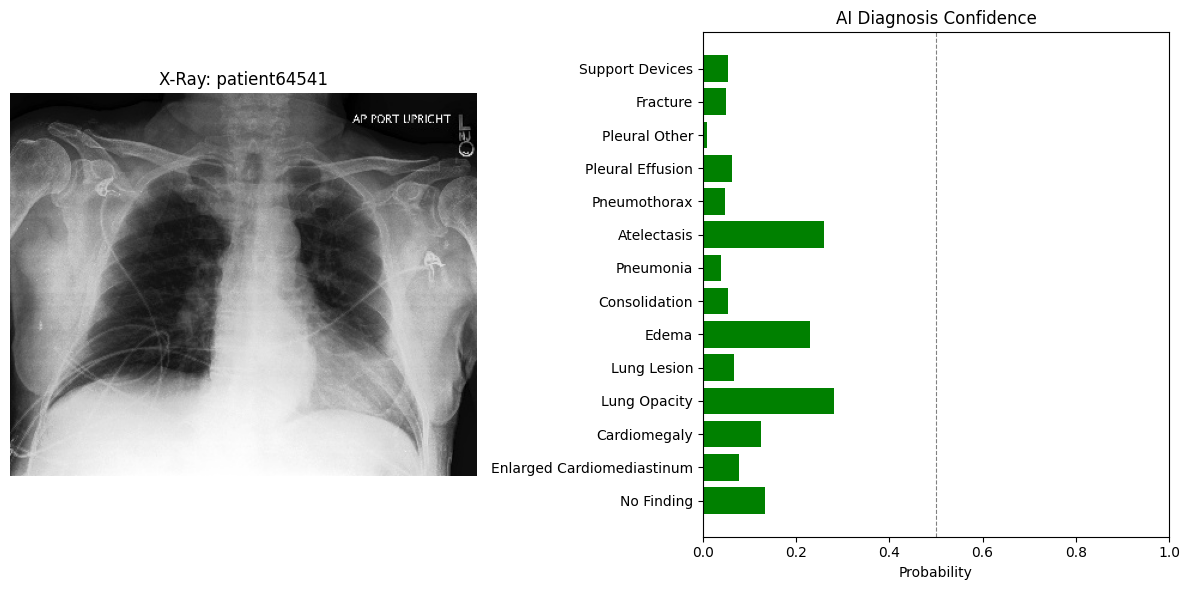


📋 REPORT FOR patient64541
------------------------------
✅ No pathologies detected.


In [18]:
predict_patient('patient64541')

In [20]:
import pandas as pd

# 1. Load Data
valid_df = pd.read_csv("/kaggle/input/chexpert/valid.csv")

# 2. Filter for POSITIVE cases (1.0)
# We look for patients who have Cardiomegaly OR Edema (Fluid in lungs)
sick_patients = valid_df[
    (valid_df['Cardiomegaly'] == 1.0) | 
    (valid_df['Edema'] == 1.0)
]

print(f"found {len(sick_patients)} sick patients.")
print("-" * 30)

# 3. Print the first 5 unique IDs (skipping patient64541 since we already tested it)
count = 0
seen_ids = set()

for idx, row in sick_patients.iterrows():
    path = row['Path']
    parts = path.split("/")
    patient_id = next(p for p in parts if "patient" in p)
    
    # Skip the one we already failed on
    if patient_id == "patient64541":
        continue
        
    if patient_id not in seen_ids:
        # Check which disease they have
        diseases = []
        if row['Cardiomegaly'] == 1.0: diseases.append("Cardiomegaly")
        if row['Edema'] == 1.0: diseases.append("Edema")
        
        print(f"🤒 {patient_id} has: {', '.join(diseases)}")
        seen_ids.add(patient_id)
        count += 1
    
    if count >= 5:
        break

print("-" * 30)
print("👉 Try running: predict_patient('patientXXXXX') with one of these new IDs.")

found 91 sick patients.
------------------------------
🤒 patient64543 has: Edema
🤒 patient64546 has: Cardiomegaly
🤒 patient64548 has: Cardiomegaly
🤒 patient64549 has: Cardiomegaly
🤒 patient64552 has: Cardiomegaly, Edema
------------------------------
👉 Try running: predict_patient('patientXXXXX') with one of these new IDs.


📄 Found X-Ray: /kaggle/input/chexpert/valid/patient64543/study1/view1_frontal.jpg
🧠 Loading Model...


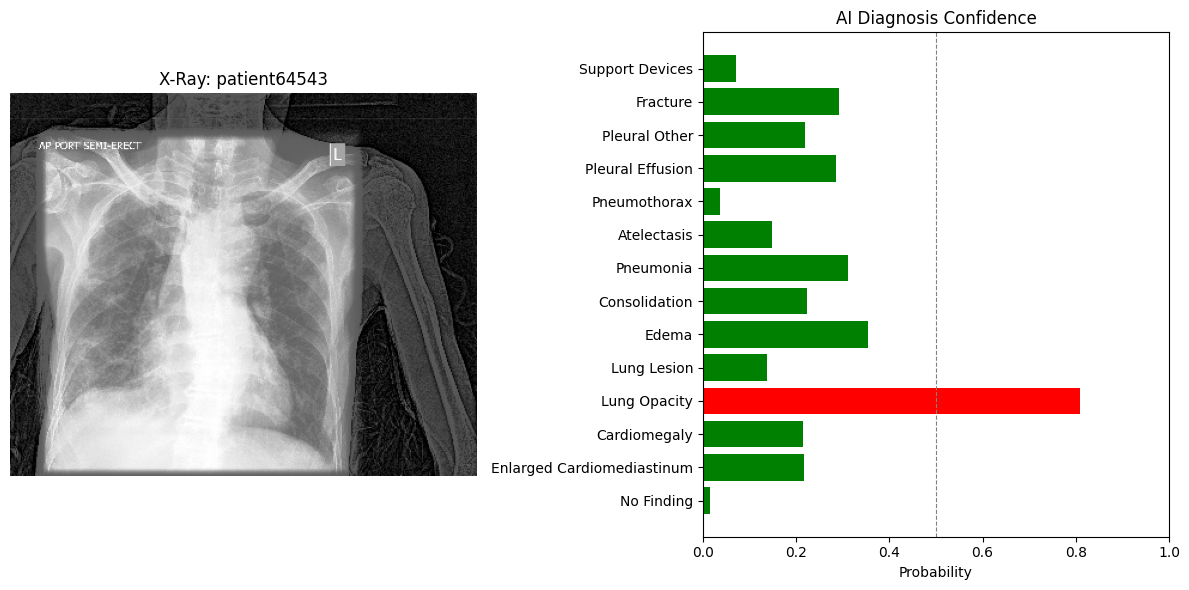


📋 REPORT FOR patient64543
------------------------------
🔴 POSITIVE: Lung Opacity (80.95%)
📄 Found X-Ray: /kaggle/input/chexpert/valid/patient64546/study1/view1_frontal.jpg
🧠 Loading Model...


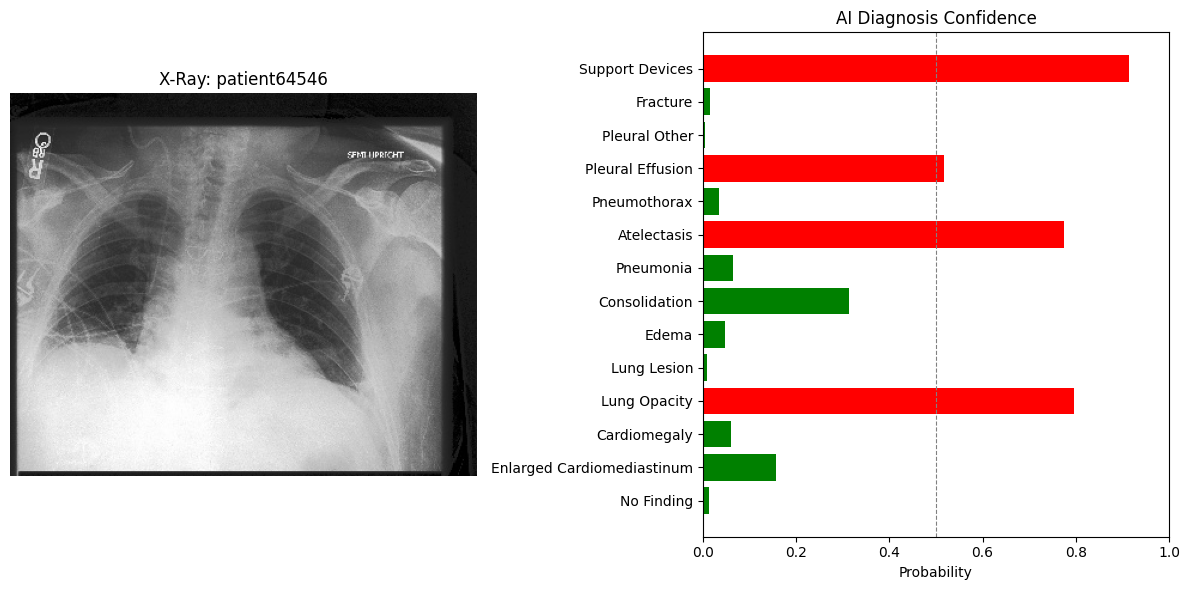


📋 REPORT FOR patient64546
------------------------------
🔴 POSITIVE: Lung Opacity (79.71%)
🔴 POSITIVE: Atelectasis (77.50%)
🔴 POSITIVE: Pleural Effusion (51.73%)
🔴 POSITIVE: Support Devices (91.31%)
📄 Found X-Ray: /kaggle/input/chexpert/valid/patient64548/study1/view1_frontal.jpg
🧠 Loading Model...


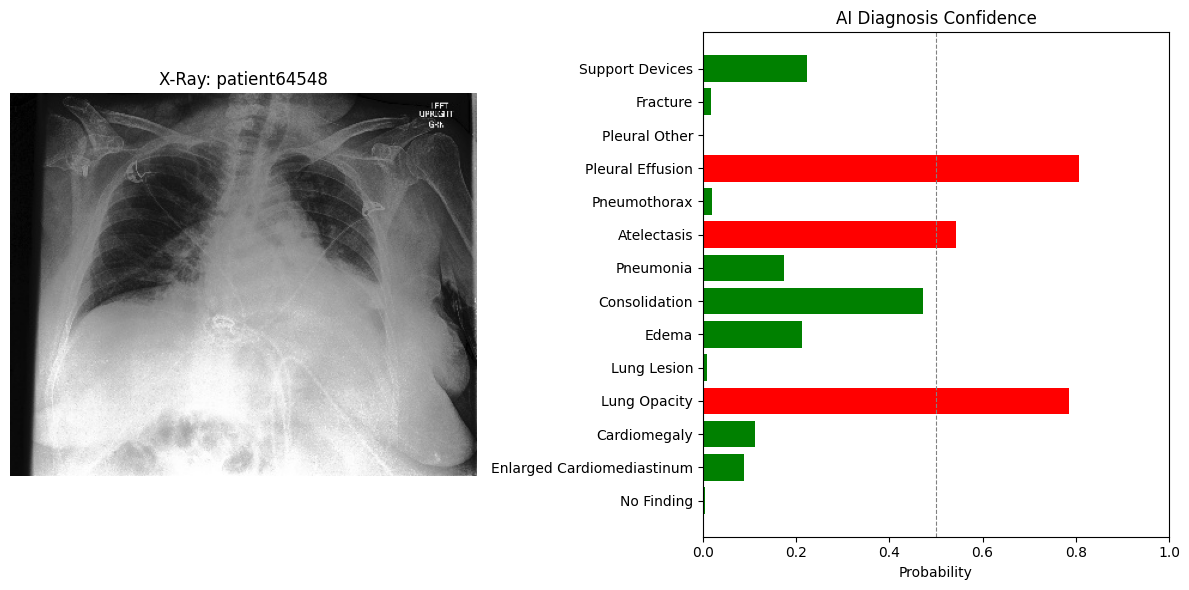


📋 REPORT FOR patient64548
------------------------------
🔴 POSITIVE: Lung Opacity (78.48%)
🔴 POSITIVE: Atelectasis (54.23%)
🔴 POSITIVE: Pleural Effusion (80.76%)
📄 Found X-Ray: /kaggle/input/chexpert/valid/patient64552/study1/view1_frontal.jpg
🧠 Loading Model...


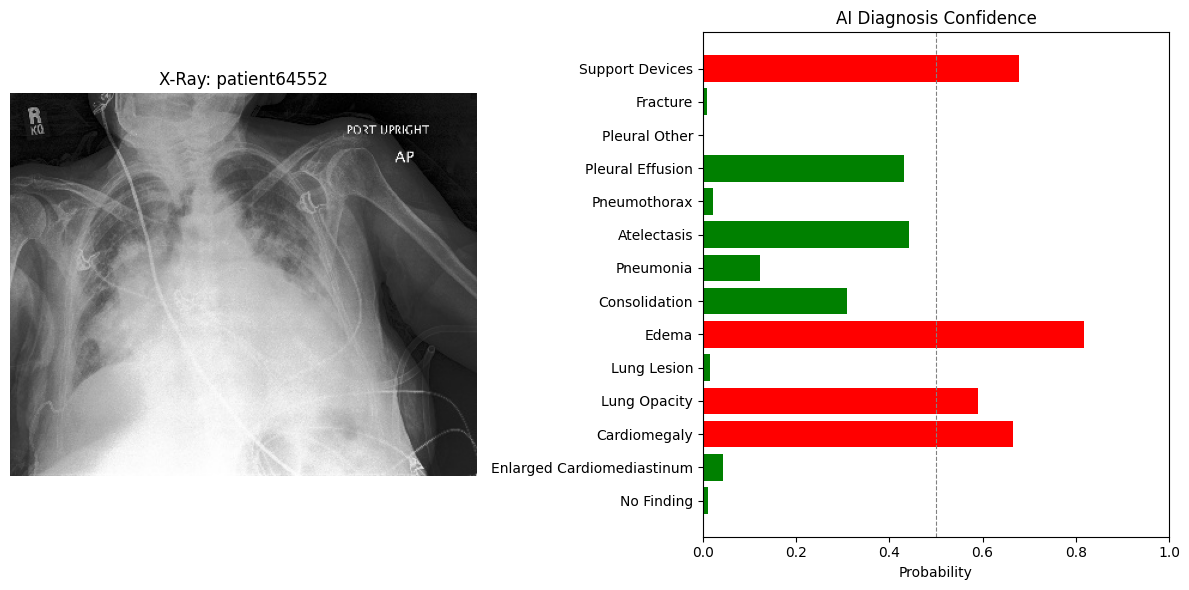


📋 REPORT FOR patient64552
------------------------------
🔴 POSITIVE: Cardiomegaly (66.47%)
🔴 POSITIVE: Lung Opacity (58.97%)
🔴 POSITIVE: Edema (81.71%)
🔴 POSITIVE: Support Devices (67.80%)


In [22]:
predict_patient('patient64543')
predict_patient('patient64546')
predict_patient('patient64548')
predict_patient('patient64552')

In [23]:
import torch
import torch.nn as nn
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import os
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report
from PIL import Image
from tqdm import tqdm # For a progress bar

# ==========================================
# 1. CONFIG & SETUP
# ==========================================
BATCH_SIZE = 32
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BASE_PATH = "/kaggle/input/chexpert/valid" 
CSV_PATH = "/kaggle/input/chexpert/valid.csv"

LABELS = [
    'No Finding', 'Enlarged Cardiomediastinum', 'Cardiomegaly', 'Lung Opacity', 
    'Lung Lesion', 'Edema', 'Consolidation', 'Pneumonia', 'Atelectasis', 
    'Pneumothorax', 'Pleural Effusion', 'Pleural Other', 'Fracture', 
    'Support Devices'
]

# ==========================================
# 2. MODEL CLASS (Must match training)
# ==========================================
class CheXpertClassifier(nn.Module):
    def __init__(self, num_classes=14):
        super(CheXpertClassifier, self).__init__()
        self.backbone = models.densenet121(weights=None)
        num_features = self.backbone.classifier.in_features
        self.backbone.classifier = nn.Sequential(
            nn.Linear(num_features, num_classes)
        )
        
    def forward(self, x):
        return self.backbone(x)

# ==========================================
# 3. DATASET CLASS (For Validation)
# ==========================================
class CheXpertValidDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        self.data = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform
        
    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # Path fix: remove "CheXpert-v1.0-small/" if present
        csv_path = self.data.iloc[idx, 0]
        clean_path = csv_path.replace("CheXpert-v1.0-small/", "")
        
        # Valid set is usually inside a folder like /kaggle/input/chexpert
        # We need to construct the path carefully
        # If root_dir ends in 'valid', and clean_path starts with 'valid', we avoid double 'valid'
        if self.root_dir.endswith("valid") and clean_path.startswith("valid/"):
            clean_path = clean_path.replace("valid/", "")
            
        full_path = os.path.join(self.root_dir, clean_path)
        
        image = Image.open(full_path).convert("RGB")
        
        # Get labels
        labels = self.data.iloc[idx][LABELS].values.astype(float)
        # In validation set, 0=Negative, 1=Positive, -1=Uncertain
        # Standard benchmark approach: Treat Uncertain (-1) as Positive (1) for recall
        # OR Treat Uncertain (-1) as Negative (0)
        # Let's use u-ones policy to match training
        labels = np.where(labels == -1.0, 1.0, labels)
        labels = np.nan_to_num(labels, nan=0.0)
        
        if self.transform:
            image = self.transform(image)
            
        return image, torch.tensor(labels, dtype=torch.float32)

# ==========================================
# 4. EVALUATION LOOP
# ==========================================
def evaluate_model():
    print("🚀 Starting Evaluation...")
    
    # A. Load Data
    val_transform = transforms.Compose([
        transforms.Resize((320, 320)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    
    # We verify where the 'valid' folder actually is relative to the CSV
    # Based on your previous success: 
    # CSV is at /kaggle/input/chexpert/valid.csv
    # Images are at /kaggle/input/chexpert/valid/...
    # So root_dir should be /kaggle/input/chexpert/valid
    
    val_dataset = CheXpertValidDataset(CSV_PATH, BASE_PATH, transform=val_transform)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    
    # B. Load Model
    model = CheXpertClassifier(num_classes=14)
    try:
        state_dict = torch.load("chexpert_model_2gpu.pth", map_location="cpu")
        new_state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}
        model.load_state_dict(new_state_dict)
        model.to(DEVICE)
        model.eval()
        print("✅ Model loaded successfully.")
    except Exception as e:
        print(f"❌ Error loading model: {e}")
        return

    # C. Run Inference
    y_true = []
    y_pred = []
    
    print(f"📊 Processing {len(val_dataset)} images...")
    with torch.no_grad():
        for images, labels in tqdm(val_loader):
            images = images.to(DEVICE)
            outputs = model(images)
            preds = torch.sigmoid(outputs)
            
            y_true.append(labels.numpy())
            y_pred.append(preds.cpu().numpy())
            
    # Concatenate all batches
    y_true = np.vstack(y_true)
    y_pred = np.vstack(y_pred)
    
    # D. Calculate Metrics
    print("\n" + "="*40)
    print(f"{'Pathology':<30} | {'AUROC':<10} | {'Accuracy':<10}")
    print("="*40)
    
    auroc_scores = []
    
    for i, label in enumerate(LABELS):
        # AUROC
        try:
            auroc = roc_auc_score(y_true[:, i], y_pred[:, i])
        except ValueError:
            auroc = 0.5 # Handle edge cases with no positive samples
        auroc_scores.append(auroc)
        
        # Accuracy (Threshold 0.5)
        # We round predictions to 0 or 1
        pred_binary = (y_pred[:, i] > 0.5).astype(int)
        acc = accuracy_score(y_true[:, i], pred_binary)
        
        print(f"{label:<30} | {auroc:.4f}     | {acc:.4f}")
        
    print("="*40)
    print(f"🏆 MEAN AUROC: {np.mean(auroc_scores):.4f}")
    print("="*40)

# --- RUN IT ---
evaluate_model()

🚀 Starting Evaluation...
✅ Model loaded successfully.
📊 Processing 234 images...


100%|██████████| 8/8 [00:03<00:00,  2.52it/s]


Pathology                      | AUROC      | Accuracy  
No Finding                     | 0.8867     | 0.8376
Enlarged Cardiomediastinum     | 0.4517     | 0.5385
Cardiomegaly                   | 0.7641     | 0.7350
Lung Opacity                   | 0.9040     | 0.7991
Lung Lesion                    | 0.6824     | 0.9915
Edema                          | 0.9456     | 0.8974
Consolidation                  | 0.8896     | 0.8547
Pneumonia                      | 0.7306     | 0.9573
Atelectasis                    | 0.8409     | 0.7350
Pneumothorax                   | 0.9071     | 0.9615
Pleural Effusion               | 0.9313     | 0.8632
Pleural Other                  | 0.8927     | 0.9957
Fracture                       | 0.5000     | 0.9872
Support Devices                | 0.9446     | 0.8932
🏆 MEAN AUROC: 0.8051


📄 Analyzing X-Ray: /kaggle/input/chexpert/valid/patient64552/study1/view1_frontal.jpg
🔍 Explaining Top Prediction: Edema (81.7%)


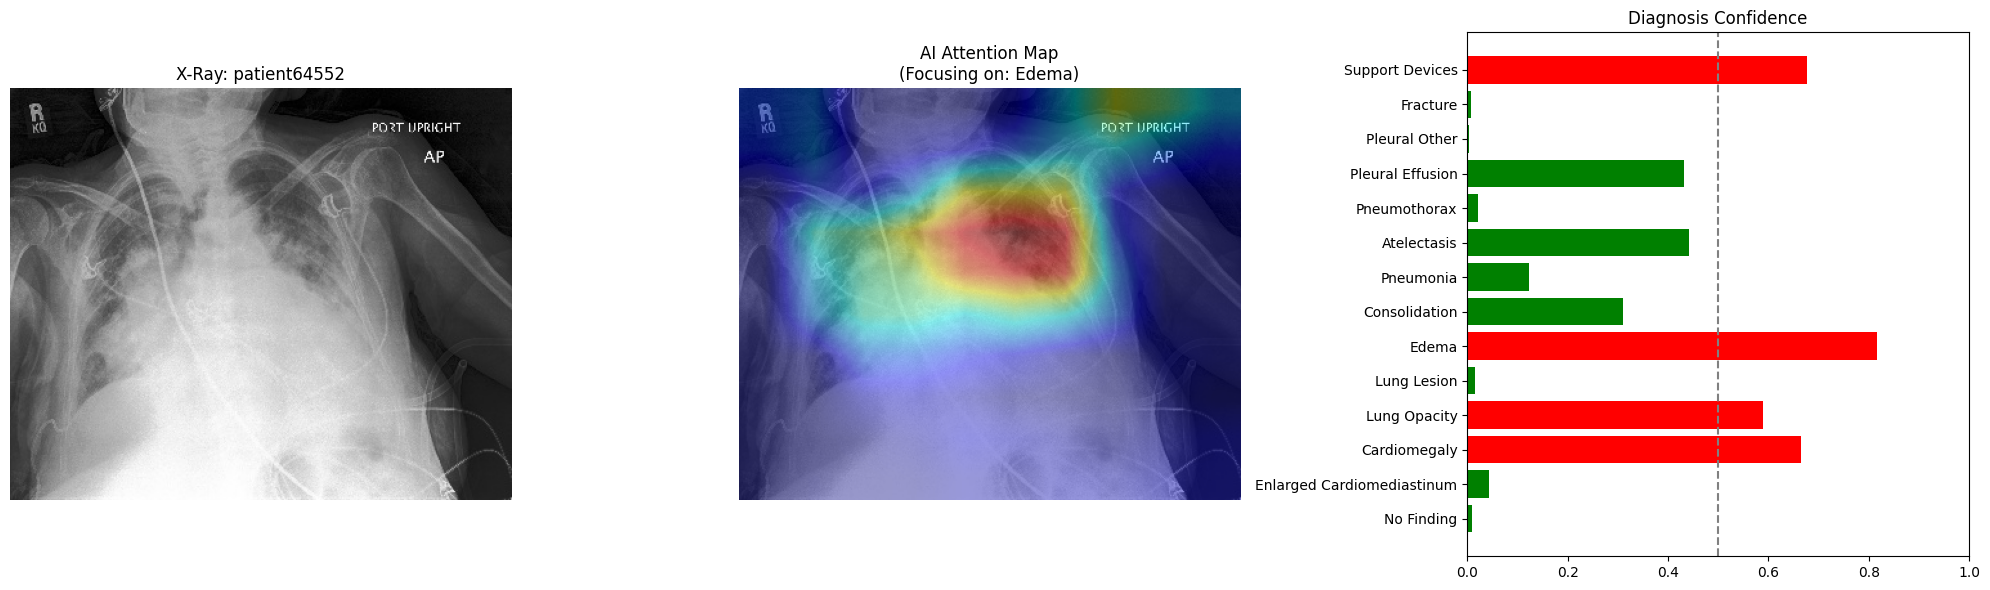

In [25]:
import torch
import torch.nn as nn
import torch.nn.functional as F  # <--- Added this import
from torchvision import transforms, models
from PIL import Image
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

# ==========================================
# 1. SETUP
# ==========================================
PATIENT_ID = "patient64552"
BASE_PATH = "/kaggle/input/chexpert/valid"
MODEL_PATH = "chexpert_model_2gpu.pth"

LABELS = [
    'No Finding', 'Enlarged Cardiomediastinum', 'Cardiomegaly', 'Lung Opacity', 
    'Lung Lesion', 'Edema', 'Consolidation', 'Pneumonia', 'Atelectasis', 
    'Pneumothorax', 'Pleural Effusion', 'Pleural Other', 'Fracture', 
    'Support Devices'
]

# ==========================================
# 2. FIXED MODEL DEFINITION
# ==========================================
class CheXpertClassifier(nn.Module):
    def __init__(self, num_classes=14):
        super(CheXpertClassifier, self).__init__()
        self.backbone = models.densenet121(weights=None)
        num_features = self.backbone.classifier.in_features
        self.backbone.classifier = nn.Sequential(
            nn.Linear(num_features, num_classes)
        )
        
    def forward(self, x):
        # --- THE FIX IS HERE ---
        # Instead of calling self.backbone(x), we manually run the steps 
        # so we can set inplace=False for the ReLU.
        
        features = self.backbone.features(x)
        out = F.relu(features, inplace=False) # <--- This prevents the crash!
        
        # Standard DenseNet ending:
        out = F.adaptive_avg_pool2d(out, (1, 1))
        out = torch.flatten(out, 1)
        out = self.backbone.classifier(out)
        return out

# ==========================================
# 3. GRAD-CAM ENGINE
# ==========================================
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.gradients = None
        self.activations = None
        
        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate_heatmap(self):
        pooled_gradients = torch.mean(self.gradients, dim=[0, 2, 3])
        activations = self.activations[0]
        for i in range(activations.shape[0]):
            activations[i, :, :] *= pooled_gradients[i]
        heatmap = torch.mean(activations, dim=0).cpu().detach().numpy()
        heatmap = np.maximum(heatmap, 0)
        heatmap /= np.max(heatmap) + 1e-8
        return heatmap

# ==========================================
# 4. ANALYSIS FUNCTION
# ==========================================
def analyze_patient(patient_id):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    
    # Locate Image
    patient_path = os.path.join(BASE_PATH, patient_id, "study1")
    try:
        img_file = [f for f in os.listdir(patient_path) if f.endswith('.jpg')][0]
        full_path = os.path.join(patient_path, img_file)
        print(f"📄 Analyzing X-Ray: {full_path}")
    except:
        print("❌ Image not found.")
        return

    # Load Model
    model = CheXpertClassifier(num_classes=14)
    if not os.path.exists(MODEL_PATH):
        print(f"❌ Error: {MODEL_PATH} not found.")
        return
        
    state_dict = torch.load(MODEL_PATH, map_location=device)
    new_state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}
    model.load_state_dict(new_state_dict)
    model.to(device)
    model.eval()

    # Target Layer for XAI
    target_layer = model.backbone.features.norm5
    grad_cam = GradCAM(model, target_layer)

    # Process Image
    transform = transforms.Compose([
        transforms.Resize((320, 320)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    
    original_pil = Image.open(full_path).convert("RGB")
    original_cv = np.array(original_pil)
    
    img_tensor = transform(original_pil).unsqueeze(0).to(device)
    img_tensor.requires_grad = True

    # Forward Pass
    model.zero_grad()
    output = model(img_tensor)
    probs = torch.sigmoid(output).cpu().detach().numpy()[0]
    
    # Backward Pass (Explanation)
    top_idx = np.argmax(probs)
    top_label = LABELS[top_idx]
    top_score = probs[top_idx]
    print(f"🔍 Explaining Top Prediction: {top_label} ({top_score:.1%})")
    
    output[:, top_idx].backward()
    
    # Generate Heatmap
    heatmap = grad_cam.generate_heatmap()
    heatmap = cv2.resize(heatmap, (original_cv.shape[1], original_cv.shape[0]))
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(original_cv, 0.6, heatmap_colored, 0.4, 0)

    # Visualize
    plt.figure(figsize=(20, 6))

    plt.subplot(1, 3, 1)
    plt.imshow(original_pil)
    plt.title(f"X-Ray: {patient_id}")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(overlay)
    plt.title(f"AI Attention Map\n(Focusing on: {top_label})")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    colors = ['green' if p < 0.5 else 'red' for p in probs]
    y_pos = np.arange(len(LABELS))
    plt.barh(y_pos, probs, align='center', color=colors)
    plt.yticks(y_pos, LABELS)
    plt.xlim(0, 1.0)
    plt.axvline(x=0.5, color='gray', linestyle='--')
    plt.title("Diagnosis Confidence")

    plt.tight_layout()
    plt.show()

# --- RUN IT ---
analyze_patient(PATIENT_ID)